# كشف الاحتيال في مدفوعات الموبايل باستخدام تعلم الآلة
### Mobile Money Fraud Detection using Machine Learning

**إعداد الطالبين:** أحمد علي المتوكل — محمد نجيب العواضي
**المقرر:** علم البيانات (مشروع تطبيقي) — بإشراف د. إسراء

**الخوارزميات المطبّقة:** الانحدار اللوجستي (Logistic Regression) وخوارزمية الجيران الأقربين (KNN) — كلاهما من قائمة الخوارزميات المعتمدة في المقرر.

يوثّق هذا الدفتر المشروع كاملاً في أربع مراحل: استكشاف البيانات (EDA)، ثم المعالجة وهندسة الميزات، ثم النمذجة والتقييم، وأخيراً تحليل النتائج والاستنتاجات.

**البيانات:** معاملات الموبايل موني — مجموعة تركيبية منشورة ضمن ورقة IEEE Access 2024 على Mendeley Data — **1,720,181 معاملة × 10 أعمدة**.

> لتنفيذ الدفتر: ضع الملف `mobile_money_fraud.csv` في مجلد `data/` بجوار الدفتر (أو عدّل المسار في خلية الإعداد). زمن التنفيذ الكامل حوالي 5 دقائق.

## الإعداد العام

نحمّل المكتبات اللازمة ونهيئ دالة مساعدة لعرض النصوص العربية في الرسوم البيانية؛ إذ لا يدعم matplotlib الاتجاه من اليمين إلى اليسار تلقائياً، فنستخدم مكتبة `arabic-reshaper` لتوصيل الحروف و`python-bidi` لعكس اتجاه النص. كما نثبّت بذرة عشوائية موحّدة (42) لضمان قابلية تكرار النتائج، ونبحث عن ملف البيانات في مواقعه المعتادة.

In [1]:
# -*- coding: utf-8 -*-
# ===== الإعداد العام: المكتبات والدوال المساعدة =====
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve)

# ---- تهيئة العربية في الرسوم + عرض الرسوم داخل الدفتر ----
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")
sns.set_context("notebook")
%matplotlib inline


def ar(text):
    """تهيئة نص عربي للعرض الصحيح داخل matplotlib (توصيل + عكس اتجاه)"""
    return get_display(arabic_reshaper.reshape(str(text)))


# ---- المسارات: نبحث عن ملف البيانات في المواقع المعتادة ----
DATA_PATH = os.environ.get("FRAUD_DATA")
if DATA_PATH is None:
    for _cand in ["data/mobile_money_fraud.csv",
                  "../download/mobile_money_fraud.csv",
                  "mobile_money_fraud.csv"]:
        if os.path.exists(_cand):
            DATA_PATH = _cand
            break
print("ملف البيانات :", DATA_PATH)

# ---- ثوابت التجربة (قابلية التكرار) ----
RANDOM_STATE = 42            # بذرة العشوائية الموحدة
KNN_SAMPLE = 150_000         # عينة طبقية لتسريع KNN (خوارزمية كثيفة الحساب)
KNN_K_CAND = [3, 7, 15]      # مرشحات k للتحقق

# ---- ألوان موحدة عبر كل الرسوم ----
C_FRAUD, C_LEGAL = "#C0392B", "#2E86AB"   # احتيال / شرعي
C_LR, C_KNN = "#1F618D", "#148F77"        # الانحدار اللوجستي / KNN
C_RULE, C_DUMB = "#E67E22", "#95A5A6"     # القاعدة البسيطة / النموذج الساذج
print("جاهز.")

ملف البيانات : ../download/mobile_money_fraud.csv
جاهز.


## المرحلة الأولى: استكشاف البيانات (EDA)

نبدأ بفهم بنية البيانات وجودتها (الأبعاد، الأعمدة، القيم المفقودة، الصفوف المكررة)، ثم نحلل توزيع الفئات وأنماط الاحتيال عبر ستة رسوم استكشافية. الهدف استخلاص إشارات توجّه هندسة الميزات لاحقاً، واختيار المقاييس العادلة للتقييم بدلاً من الاكتفاء بالدقة (Accuracy) التي تُضلّ في البيانات المختلة التوازن.

In [2]:
# ===== تحميل البيانات الخام =====
df = pd.read_csv(DATA_PATH)
print(f"الأبعاد: {df.shape[0]:,} صف × {df.shape[1]} عمود")
df.head()

الأبعاد: 1,720,181 صف × 10 عمود


,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


In [3]:
# ===== فحص الجودة: الأنواع، القيم المفقودة، الصفوف المكررة =====
df.info()
print()
print(f"إجمالي القيم المفقودة : {int(df.isna().sum().sum())}")
print(f"إجمالي الصفوف المكررة : {int(df.duplicated().sum())}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   transactionType  object 
 2   amount           float64
 3   initiator        int64  
 4   oldBalInitiator  float64
 5   newBalInitiator  float64
 6   recipient        object 
 7   oldBalRecipient  float64
 8   newBalRecipient  float64
 9   isFraud          int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 131.2+ MB

إجمالي القيم المفقودة : 0


إجمالي الصفوف المكررة : 0


### 1) توزيع الفئات (شرعي / احتيال)

نلاحظ اختلالاً واضحاً في توازن الفئات: نحو 90% من المعاملات شرعية و10% احتيال. هذا الاختلال يعني أن نموذجاً أحمق يتوقع «شرعي» دائماً سيحقق دقة ~90% دون أن يمسك بعملية احتيال واحدة — لذلك سنقيّم لاحقاً بالمقاييس التي تكشف هذا الخداع (الضبط Precision والاستدعاء Recall معاً).

معاملات شرعية : 1,544,663  (89.8%)
عمليات احتيال : 175,518  (10.2%)


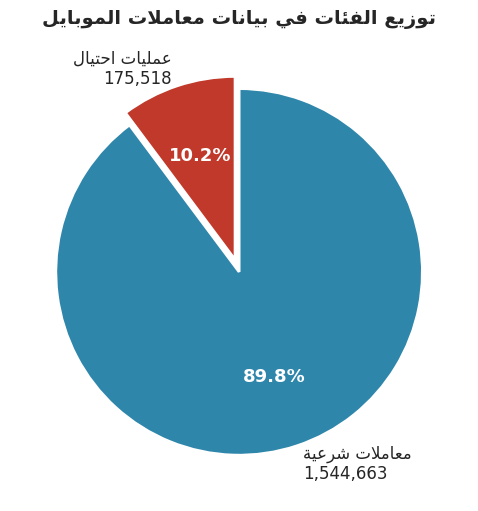

In [4]:
# ===== توزيع الفئات =====
counts = df["isFraud"].value_counts()
n_legal, n_fraud = int(counts.get(0, 0)), int(counts.get(1, 0))
fraud_rate = n_fraud / len(df) * 100
print(f"معاملات شرعية : {n_legal:,}  ({100 - fraud_rate:.1f}%)")
print(f"عمليات احتيال : {n_fraud:,}  ({fraud_rate:.1f}%)")

# ---- الرسم 1: توزيع الفئات ----
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
wedges, texts, autotexts = ax.pie(
    [n_legal, n_fraud],
    labels=[ar(f"معاملات شرعية\n{n_legal:,}"), ar(f"عمليات احتيال\n{n_fraud:,}")],
    colors=[C_LEGAL, C_FRAUD],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90, counterclock=False, explode=(0, 0.07),
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 2})
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold"); t.set_fontsize(13)
ax.set_title(ar("توزيع الفئات في بيانات معاملات الموبايل"),
            fontsize=14, fontweight="bold", pad=14)
plt.show()

### 2) الاحتيال حسب نوع العملية

السؤال الأهم: هل يتوزع الاحتيال بالتساوي على أنواع العمليات الخمسة، أم يتركز في نوع بعينه؟ الإجابة في الرسم التالي.

,total,fraud,legal,fraud_rate
transactionType,,,,
PAYMENT,667245,0,667245,0.00%
TRANSFER,569328,175518,393810,30.83%
DEPOSIT,384431,0,384431,0.00%
WITHDRAWAL,93785,0,93785,0.00%
DEBIT,5392,0,5392,0.00%


أنواع العمليات التي يحدث فيها احتيال: ['TRANSFER']


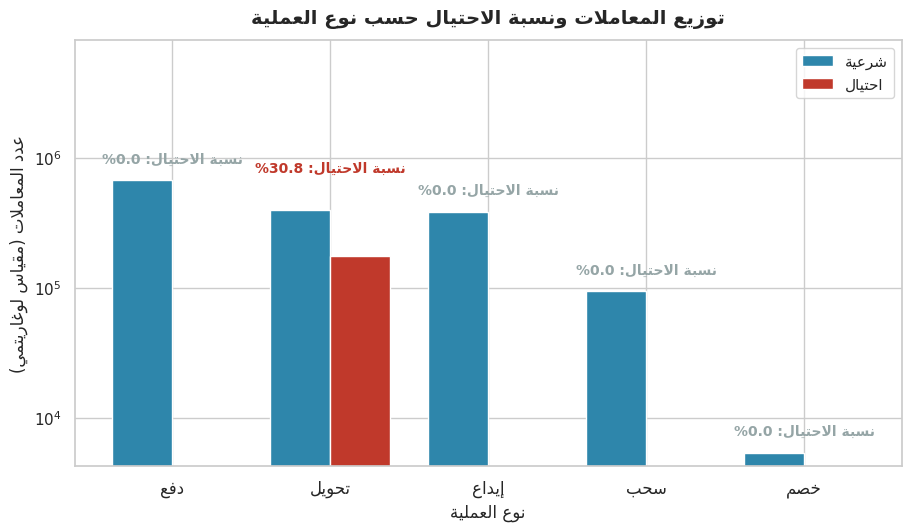

In [5]:
# ===== الاحتيال حسب نوع العملية =====
AR_TYPE = {"TRANSFER": "تحويل", "PAYMENT": "دفع", "DEPOSIT": "إيداع",
           "WITHDRAWAL": "سحب", "DEBIT": "خصم"}

type_tbl = df.groupby("transactionType")["isFraud"].agg(total="count", fraud="sum")
type_tbl["legal"] = type_tbl["total"] - type_tbl["fraud"]
type_tbl["fraud_rate"] = type_tbl["fraud"] / type_tbl["total"] * 100
type_tbl = type_tbl.sort_values("total", ascending=False)
display(type_tbl.style.format({"fraud_rate": "{:.2f}%"}))
fraud_types = type_tbl[type_tbl["fraud"] > 0].index.tolist()
print(f"أنواع العمليات التي يحدث فيها احتيال: {fraud_types}")

# ---- الرسم 2: توزيع المعاملات ونسبة الاحتيال حسب النوع ----
fig, ax = plt.subplots(figsize=(9, 5.2), constrained_layout=True)
x = np.arange(len(type_tbl)); w = 0.38
ax.bar(x - w / 2, type_tbl["legal"], width=w, color=C_LEGAL,
       label=ar("شرعية"), edgecolor="white")
ax.bar(x + w / 2, type_tbl["fraud"], width=w, color=C_FRAUD,
       label=ar("احتيال"), edgecolor="white")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([ar(AR_TYPE.get(t, t)) for t in type_tbl.index], fontsize=12)
ax.set_xlabel(ar("نوع العملية"), fontsize=12)
ax.set_ylabel(ar("عدد المعاملات (مقياس لوغاريتمي)"), fontsize=12)
for i, (idx, row) in enumerate(type_tbl.iterrows()):
    ax.annotate(ar(f"نسبة الاحتيال: {row.fraud_rate:.1f}%"),
                xy=(i, row.total * 1.35), ha="center", fontsize=10,
                color=C_FRAUD if row.fraud > 0 else "#95A5A6", fontweight="bold")
ax.set_ylim(top=type_tbl["total"].max() * 12)
ax.legend(loc="upper right", fontsize=11, frameon=True)
ax.set_title(ar("توزيع المعاملات ونسبة الاحتيال حسب نوع العملية"),
            fontsize=14, fontweight="bold", pad=12)
plt.show()

**اكتشاف محوري:** الاحتيال يقع **حصرياً** في عمليات TRANSFER (تحويل)، بنسبة 30.8% من التحويلات، وصفر تماماً في بقية الأنواع. هذه أقوى إشارة في البيانات كلها (AUC = 0.873)، وستصبح لاحقاً «قاعدة بسيطة» نقارن بها النماذج.

In [6]:
# ===== تحليل نوع الحساب: تاجر مقابل فرد =====
# حسابات التجار تظهر في عمود المستقبِل بالصيغة "XX-XXXXXXX" (تحتوي شرطة)
df["isMerchant"] = df["recipient"].astype(str).str.contains("-", na=False)
merch = df.groupby("isMerchant")["isFraud"].agg(total="count", fraud="sum")
merch["rate_pct"] = merch["fraud"] / merch["total"] * 100
display(merch)
print("ملاحظة: جميع المُرسلين حسابات فردية (عمود initiator رقمي بالكامل)")

,total,fraud,rate_pct
isMerchant,,,
False,569328,175518,30.828977
True,1150853,0,0.000000


ملاحظة: جميع المُرسلين حسابات فردية (عمود initiator رقمي بالكامل)


### 3) تحليل المبالغ

هل تختلف مبالغ عمليات الاحتيال عن الشرعية؟ استخدمنا مقياساً لوغاريتمياً لأن المبالغ تمتد عبر عدة مراتب عددية، ولأن كثافة الاحتيال منخفضة رسمنا الكثافة النسبية بدل العدد المطلق.

,count,mean,std,min,25%,50%,75%,max
مبالغ الاحتيال,"175,518.00","25,486.86","17,980.36","16,804.02","17,084.69","19,631.62","24,615.56","632,938.42"
المبالغ الشرعية,"1,544,663.00","55,612.54","92,545.22",0.24,599.78,"17,062.90","78,638.27","2,142,928.28"


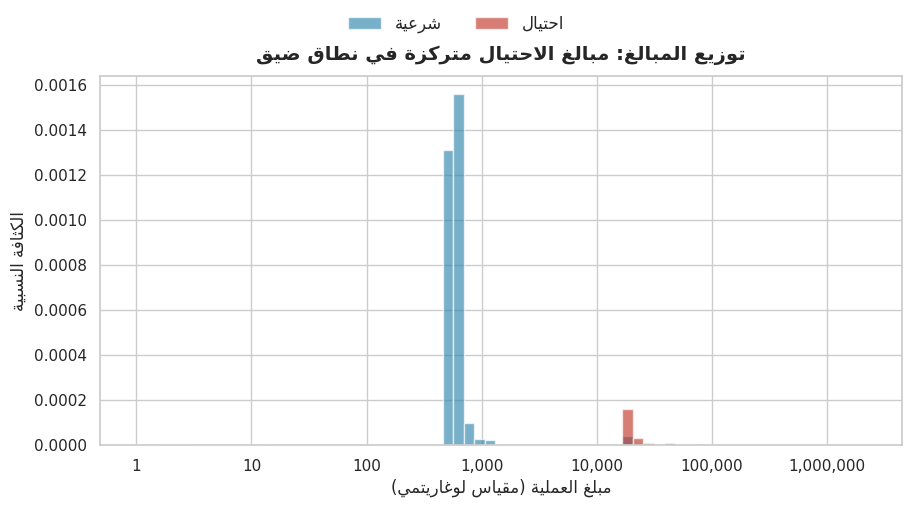

In [7]:
# ===== إحصاءات المبالغ: احتيال مقابل شرعي =====
amt_stats = pd.DataFrame({
    "مبالغ الاحتيال": df.loc[df["isFraud"] == 1, "amount"].describe(),
    "المبالغ الشرعية": df.loc[df["isFraud"] == 0, "amount"].describe(),
}).T
display(amt_stats.style.format("{:,.2f}"))

# ---- الرسم 3: توزيع المبالغ ----
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
bins = np.logspace(0, np.log10(df["amount"].max() + 1), 70)
ax.hist(df.loc[df["isFraud"] == 0, "amount"], bins=bins, density=True,
        color=C_LEGAL, alpha=0.65, label=ar("شرعية"))
ax.hist(df.loc[df["isFraud"] == 1, "amount"], bins=bins, density=True,
        color=C_FRAUD, alpha=0.65, label=ar("احتيال"))
ax.set_xscale("log")
ax.set_xlabel(ar("مبلغ العملية (مقياس لوغاريتمي)"), fontsize=12)
ax.set_ylabel(ar("الكثافة النسبية"), fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f"{int(v):,}" if v >= 1 else f"{v}"))
fig.legend(loc="outside upper center", ncol=2, fontsize=12, frameon=False)
ax.set_title(ar("توزيع المبالغ: مبالغ الاحتيال متركزة في نطاق ضيق"),
            fontsize=14, fontweight="bold", pad=12)
plt.show()

### 4) الأرصدة السالبة والارتباطات

اكتشف الفحص أرصدة سالبة بعد العملية (ظاهرة «السحب على المكشوف» في المحاكاة) — سنقرر مصيرها في مرحلة المعالجة. بعدها نرسم مصفوفة الارتباط بين المتغيرات الرقمية للبحث عن علاقات خطية مباشرة مع الاحتيال.

In [8]:
# ===== فحص الأرصدة السالبة =====
neg_init = int((df["newBalInitiator"] < 0).sum())
neg_recip = int((df["newBalRecipient"] < 0).sum())
min_bal = float(df[["oldBalInitiator", "newBalInitiator",
                    "oldBalRecipient", "newBalRecipient"]].min().min())
print(f"صفوف برصيد مُرسل سالب بعد العملية  : {neg_init:,}")
print(f"صفوف برصيد مستقبِل سالب بعد العملية : {neg_recip:,}")
print(f"أدنى رصيد في البيانات              : {min_bal:,.2f}")

# ===== الارتباطات مع الاحتيال =====
num_cols = ["step", "amount", "oldBalInitiator", "newBalInitiator",
            "oldBalRecipient", "newBalRecipient", "isFraud"]
corr = df[num_cols].corr()
print("\nالارتباط مع isFraud (تنازلياً):")
print(corr["isFraud"].sort_values(ascending=False).to_string())

صفوف برصيد مُرسل سالب بعد العملية  : 44,621
صفوف برصيد مستقبِل سالب بعد العملية : 15
أدنى رصيد في البيانات              : -199,997.11



الارتباط مع isFraud (تنازلياً):
isFraud            1.000000
step               0.044108
oldBalInitiator   -0.046670
newBalRecipient   -0.051472
newBalInitiator   -0.055645
oldBalRecipient   -0.069021
amount            -0.103205


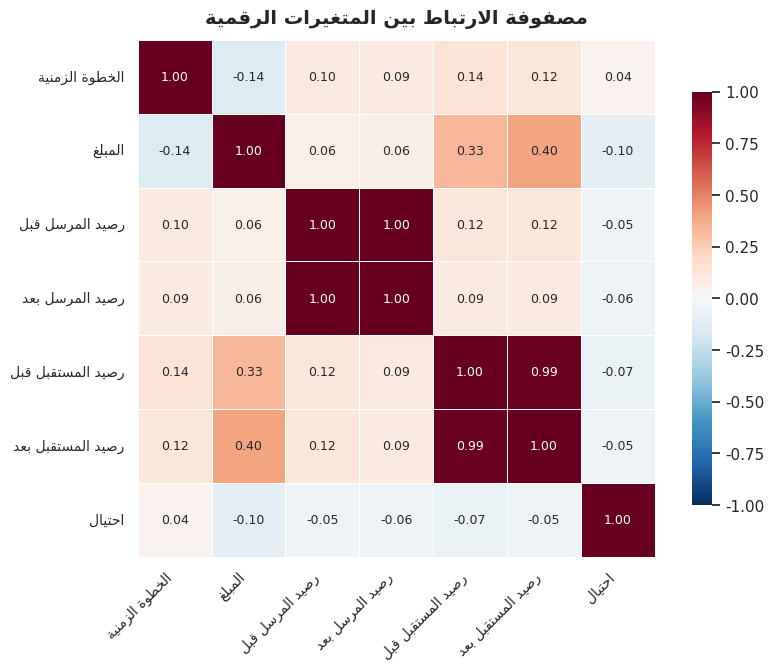

In [9]:
# ---- الرسم 4: خريطة الارتباطات ----
AR_COL = {"step": "الخطوة الزمنية", "amount": "المبلغ",
          "oldBalInitiator": "رصيد المُرسل قبل", "newBalInitiator": "رصيد المُرسل بعد",
          "oldBalRecipient": "رصيد المستقبِل قبل", "newBalRecipient": "رصيد المستقبِل بعد",
          "isFraud": "احتيال"}

fig, ax = plt.subplots(figsize=(8.6, 6.6), constrained_layout=True)
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
labels_ar = [ar(AR_COL.get(c, c)) for c in corr.columns]
ax.set_xticklabels(labels_ar, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(labels_ar, rotation=0, fontsize=10)
ax.set_title(ar("مصفوفة الارتباط بين المتغيرات الرقمية"),
            fontsize=14, fontweight="bold", pad=12)
plt.show()

### 5) علاقة الاحتيال باستنزاف رصيد المُرسل

فرضية شائعة في أدبيات الاحتيال: المحتال يستنزف كامل رصيد الضحية. نفحصها برسم المبلغ مقابل الرصيد قبل العملية على عينة عشوائية (40 ألف عملية)، مع خط المرجع «المبلغ = كامل الرصيد».

متوسط نسبة الاستنزاف (احتيال): 1.569
متوسط نسبة الاستنزاف (شرعي)  : 58.663


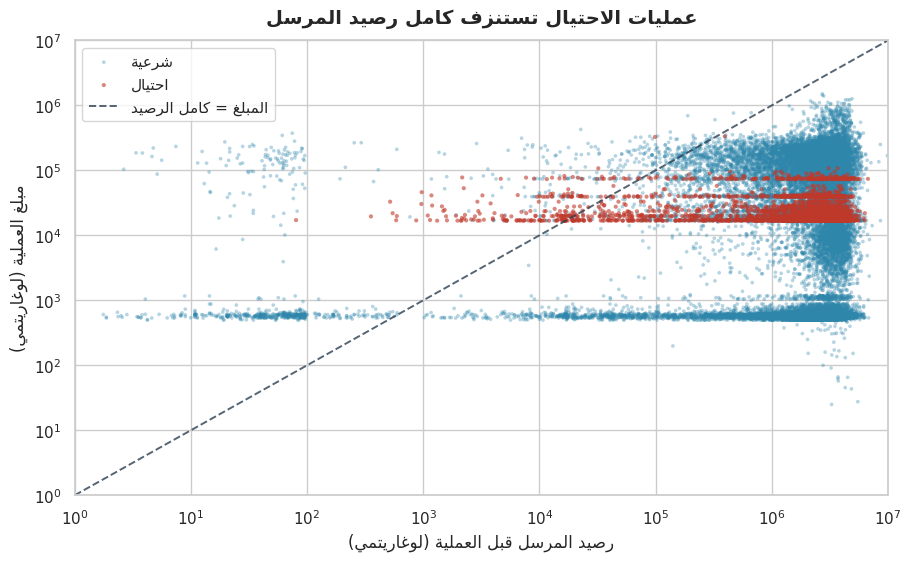

In [10]:
# ===== نسبة استنزاف الرصيد =====
df["drain_ratio"] = np.where(df["oldBalInitiator"] > 0,
                             df["amount"] / (df["oldBalInitiator"] + 1e-9), np.nan)
dr_f = df.loc[df["isFraud"] == 1, "drain_ratio"]
dr_l = df.loc[df["isFraud"] == 0, "drain_ratio"]
print(f"متوسط نسبة الاستنزاف (احتيال): {dr_f.mean():.3f}")
print(f"متوسط نسبة الاستنزاف (شرعي)  : {dr_l.mean():.3f}")

# ---- الرسم 5: المبلغ مقابل الرصيد قبل العملية ----
rng = np.random.default_rng(42)
samp = df.iloc[rng.choice(len(df), size=40000, replace=False)]
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
leg = samp[(samp["isFraud"] == 0) & (samp["oldBalInitiator"] > 0)]
frd = samp[(samp["isFraud"] == 1) & (samp["oldBalInitiator"] > 0)]
ax.scatter(leg["oldBalInitiator"], leg["amount"], s=7, alpha=0.35,
           color=C_LEGAL, label=ar("شرعية"), edgecolors="none")
ax.scatter(frd["oldBalInitiator"], frd["amount"], s=9, alpha=0.6,
           color=C_FRAUD, label=ar("احتيال"), edgecolors="none")
lims = [1, max(1e7, df["amount"].max())]
ax.plot(lims, lims, color="#2C3E50", linestyle="--", linewidth=1.4,
        alpha=0.8, label=ar("المبلغ = كامل الرصيد"))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(ar("رصيد المُرسل قبل العملية (لوغاريتمي)"), fontsize=12)
ax.set_ylabel(ar("مبلغ العملية (لوغاريتمي)"), fontsize=12)
ax.legend(loc="upper left", fontsize=11, frameon=True)
ax.set_title(ar("عمليات الاحتيال تستنزف كامل رصيد المُرسل"),
            fontsize=14, fontweight="bold", pad=12)
plt.show()

### 6) النمط الزمني

الخطوة الزمنية (step) تحاكي تتابع المعاملات؛ نجمّعها باليوم (24 خطوة) لمراقبة تطور حجم المعاملات ونسبة الاحتيال معاً عبر محورين.

أقصى خطوة زمنية: 143 | حجم التجميع: 1


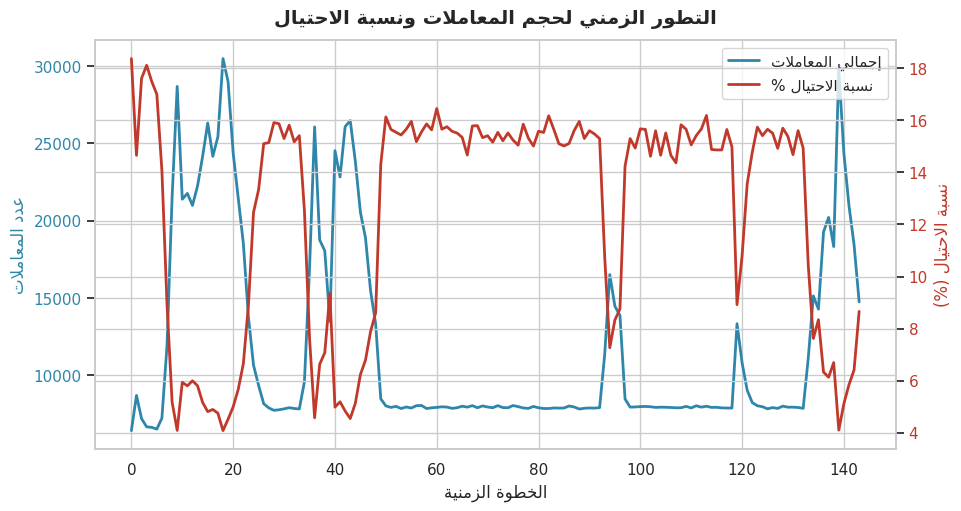

In [11]:
# ===== النمط الزمني للمعاملات والاحتيال =====
step_max = int(df["step"].max())
per_step = df.groupby("step")["isFraud"].agg(total="count", fraud="sum")
bin_size = 24 if step_max > 200 else 1   # تجميع باليوم إذا كانت الخطوات ساعات
per_step = per_step.groupby(per_step.index // bin_size).sum()
per_step["rate"] = per_step["fraud"] / per_step["total"] * 100
print(f"أقصى خطوة زمنية: {step_max} | حجم التجميع: {bin_size}")

# ---- الرسم 6: التطور الزمني ----
fig, ax1 = plt.subplots(figsize=(9.5, 5), constrained_layout=True)
t = per_step.index * bin_size
ax1.plot(t, per_step["total"], color=C_LEGAL, linewidth=2,
         label=ar("إجمالي المعاملات"))
ax1.set_xlabel(ar("الخطوة الزمنية") +
               (ar(" (مجمّعة باليوم)") if bin_size > 1 else ""), fontsize=12)
ax1.set_ylabel(ar("عدد المعاملات"), color=C_LEGAL, fontsize=12)
ax1.tick_params(axis="y", labelcolor=C_LEGAL)
ax2 = ax1.twinx()
ax2.plot(t, per_step["rate"], color=C_FRAUD, linewidth=2,
         label=ar("نسبة الاحتيال %"))
ax2.set_ylabel(ar("نسبة الاحتيال (%)"), color=C_FRAUD, fontsize=12)
ax2.tick_params(axis="y", labelcolor=C_FRAUD)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=11, frameon=True)
ax1.set_title(ar("التطور الزمني لحجم المعاملات ونسبة الاحتيال"),
              fontsize=14, fontweight="bold", pad=12)
plt.show()

## المرحلة الثانية: المعالجة وهندسة الميزات

قرارات المعالجة المستخلصة من الاستكشاف:

1. **الجودة:** لا قيم مفقودة ولا صفوف مكررة (الكود يتضمن التنظيف الشرطي احتياطاً).
2. **الأرصدة السالبة (44,631 صف):** ظاهرة حقيقية في المحاكاة (سحب على المكشوف)، فنُبقيها وننشئ لها ميزة راية (Flag) بدلاً من حذف صفوف بريئة.
3. **ترويض الالتواء:** المبالغ والأرصدة شديدة الالتواء، فنطبق تحويلاً لوغاريتمياً **موقّعاً** يحافظ على إشارة السالب.
4. **ترميز One-Hot** لنوع العملية (5 أعمدة ثنائية).
5. **ميزات سلوكية:** فجوة الرصيد (هل يستنزف المبلغ كامل رصيد المُرسل؟) وخطأ إثبات رصيد المستقبِل.

النتيجة: **16 ميزة** جاهزة للنمذجة.

In [12]:
# ===== فحص الجودة والتنظيف (احتياطي — البيانات نظيفة أصلاً) =====
# أولاً: نُسقط الأعمدة المشتقة التي أضافها الاستكشاف (isMerchant, drain_ratio)
# حتى لا تُحسب قيم drain_ratio الـ NaN (للأرصدة الصفرية) ضمن «القيم المفقودة»
eda_helper_cols = [c for c in ["drain_ratio", "isMerchant"] if c in df.columns]
df = df.drop(columns=eda_helper_cols)
print(f"أُسقطت أعمدة الاستكشاف المساعدة: {eda_helper_cols}")

n_missing = int(df.isna().sum().sum())
n_dupes = int(df.duplicated().sum())
if n_missing > 0:
    df = df.dropna()
    print(f"-> حُذفت الصفوف ذات القيم المفقودة: {n_missing}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"-> حُذفت الصفوف المكررة: {n_dupes}")
print(f"الأبعاد بعد التنظيف: {df.shape[0]:,} × {df.shape[1]}")

# قرار الأرصدة السالبة: الإبقاء + ميزة راية
neg_init = int((df["newBalInitiator"] < 0).sum())
neg_recip = int((df["newBalRecipient"] < 0).sum())
print(f"أرصدة مُرسل سالبة   : {neg_init:,} ({neg_init/len(df)*100:.2f}%) — قرار: الإبقاء + ميزة راية")
print(f"أرصدة مستقبِل سالبة : {neg_recip:,}")

أُسقطت أعمدة الاستكشاف المساعدة: ['drain_ratio', 'isMerchant']


الأبعاد بعد التنظيف: 1,720,181 × 10
أرصدة مُرسل سالبة   : 44,621 (2.59%) — قرار: الإبقاء + ميزة راية
أرصدة مستقبِل سالبة : 15


In [13]:
# ===== هندسة الميزات (16 ميزة) =====

def signed_log(x):
    """تحويل لوغاريتمي يحافظ على الإشارة (للتعامل مع الأرصدة السالبة)"""
    return np.sign(x) * np.log1p(np.abs(x))

fe = pd.DataFrame()

# (أ) المتغير الزمني
fe["step"] = df["step"].astype(np.float32)

# (ب) التحويل اللوغاريتمي الموقّع للمبالغ والأرصدة (ترويض الالتواء الشديد)
fe["log_amount"] = signed_log(df["amount"]).astype(np.float32)
fe["log_oldBalInitiator"] = signed_log(df["oldBalInitiator"]).astype(np.float32)
fe["log_newBalInitiator"] = signed_log(df["newBalInitiator"]).astype(np.float32)
fe["log_oldBalRecipient"] = signed_log(df["oldBalRecipient"]).astype(np.float32)
fe["log_newBalRecipient"] = signed_log(df["newBalRecipient"]).astype(np.float32)

# (ج) ترميز One-Hot لنوع العملية (5 ميزات)
for t in ["TRANSFER", "PAYMENT", "DEPOSIT", "WITHDRAWAL", "DEBIT"]:
    fe[f"is_{t.lower()}"] = (df["transactionType"] == t).astype(np.int8)

# (د) فجوة الرصيد: هل يستنزف المبلغ كامل رصيد المُرسل؟
fe["amount_minus_oldBal"] = (df["amount"] - df["oldBalInitiator"]).astype(np.float32)
fe["relative_gap"] = np.clip(
    (df["amount"] - df["oldBalInitiator"]) / (df["amount"] + 1.0),
    -2.0, 2.0).astype(np.float32)

# (هـ) خطأ إثبات رصيد المستقبِل (المبلغ المقيد مقابل المبلغ المرسل)
fe["dest_credit_error"] = (
    (df["newBalRecipient"] - df["oldBalRecipient"]) - df["amount"]).astype(np.float32)

# (و) رايات الأرصدة السالبة
fe["flag_negBalInitiator"] = (df["newBalInitiator"] < 0).astype(np.int8)
fe["flag_negBalRecipient"] = (df["newBalRecipient"] < 0).astype(np.int8)

# الهدف
fe["isFraud"] = df["isFraud"].astype(np.int8)

print(f"إجمالي الميزات المُنشأة: {fe.shape[1] - 1}")
print(f"الأعمدة: {list(fe.columns)}")
print(f"التوزيع: شرعية {(fe['isFraud']==0).sum():,} | احتيال {(fe['isFraud']==1).sum():,} "
      f"({(fe['isFraud']==1).mean()*100:.1f}%)")
fe.head()

إجمالي الميزات المُنشأة: 16
الأعمدة: ['step', 'log_amount', 'log_oldBalInitiator', 'log_newBalInitiator', 'log_oldBalRecipient', 'log_newBalRecipient', 'is_transfer', 'is_payment', 'is_deposit', 'is_withdrawal', 'is_debit', 'amount_minus_oldBal', 'relative_gap', 'dest_credit_error', 'flag_negBalInitiator', 'flag_negBalRecipient', 'isFraud']
التوزيع: شرعية 1,544,663 | احتيال 175,518 (10.2%)


,step,log_amount,log_oldBalInitiator,log_newBalInitiator,log_oldBalRecipient,log_newBalRecipient,is_transfer,is_payment,is_deposit,is_withdrawal,is_debit,amount_minus_oldBal,relative_gap,dest_credit_error,flag_negBalInitiator,flag_negBalRecipient,isFraud
0,0.0,9.894748,12.142671,12.031054,2.231089,9.895166,1,0,0,0,0,-167887.218750,-2.000000,0.000000,0,0,1
1,0.0,6.396880,2.294553,2.294553,0.000000,0.000000,0,1,0,0,0,590.049988,0.983466,-598.969971,0,0,0
2,0.0,6.304174,4.549657,-6.116444,0.000000,6.304174,0,1,0,0,0,452.250000,0.827009,0.000000,1,0,0
3,0.0,9.895859,-6.116444,-9.918389,8.297225,10.079947,1,0,0,0,0,20299.259766,1.022735,0.010000,1,0,1
4,0.0,6.306075,11.977601,11.974158,0.000000,6.306075,0,1,0,0,0,-158601.875000,-2.000000,0.000000,0,0,0


## المرحلة الثالثة: النمذجة والتقييم

خطة النمذجة:

1. **تقسيم طبقي 80/20** يحافظ على نسبة الاحتيال (10.2%) في جزأي التدريب والاختبار.
2. **خطا أساس (Baselines) للمقارنة العادلة:**
   - نموذج ساذج: كل المعاملات شرعية.
   - قاعدة بسيطة مستخلصة من الاستكشاف: كل تحويل = احتيال (استدعاء 100% لكنها تتهم أبرياء كثراً).
3. **الانحدار اللوجستي** على كامل البيانات (1.38 مليون صف تدريب) مع `class_weight='balanced'` لموازنة فئة الأقلية، والتقييس `StandardScaler` داخل pipeline لمنع تسرب معلومات الاختبار.
4. **خوارزمية الجيران الأقربين (KNN)** على عينة طبقية (150 ألف صف) لأنها كثيفة الحساب، مع اختيار k عبر مجموعة تحقق، ومقارنة عادلة بـ LR على العينة نفسها.
5. **التقييم** بالدقة والضبط والاستدعاء وF1 وAUC + مصفوفات الالتباس ومنحنيات ROC.

In [14]:
# ===== التقسيم الطبقي 80/20 =====
# نستخدم float64 لمطابقة خط الأنابيب المعياري (حفظ CSV ثم إعادة تحميله)
# ولفروق عددية أدق في المصنف الخطي
X = fe.drop(columns=["isFraud"]).astype(np.float64)
y = fe["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"التدريب : {len(X_train):,} صف  (نسبة الاحتيال {y_train.mean()*100:.2f}%)")
print(f"الاختبار : {len(X_test):,} صف  (نسبة الاحتيال {y_test.mean()*100:.2f}%)")
print(f"عدد الميزات: {X.shape[1]}")

results = {}   # نتائج كل النماذج تُجمع هنا

def evaluate(name, y_true, y_pred, y_prob=None, extra=None):
    """حساب المقاييس الأربعة + AUC وحفظها في قاموس النتائج"""
    res = {
        "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred,
                                                 zero_division=0)), 4),
        "recall":    round(float(recall_score(y_true, y_pred)), 4),
        "f1":        round(float(f1_score(y_true, y_pred)), 4),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    if y_prob is not None:
        res["roc_auc"] = round(float(roc_auc_score(y_true, y_prob)), 4)
    if extra:
        res.update(extra)
    results[name] = res
    print(f"[{name}]  Acc={res['accuracy']*100:.2f}% | P={res['precision']*100:.2f}% | "
          f"R={res['recall']*100:.2f}% | F1={res['f1']*100:.2f}%"
          + (f" | AUC={res['roc_auc']:.4f}" if "roc_auc" in res else ""))
    return res

التدريب : 1,376,144 صف  (نسبة الاحتيال 10.20%)
الاختبار : 344,037 صف  (نسبة الاحتيال 10.20%)
عدد الميزات: 16


In [15]:
# ===== خطا الأساس (Baselines) =====

# (أ) نموذج ساذج: كل المعاملات شرعية — يتوقع أعلى دقة لكنه يمسك صفر لص
print("— نموذج ساذج: توقع (شرعي) لكل معاملة")
evaluate("dumb_all_legal", y_test, np.zeros(len(y_test), dtype=int),
         extra={"note": "يتنبأ بأن كل معاملة شرعية"})

# (ب) قاعدة بسيطة من الاستكشاف: كل تحويل = احتيال
print("— قاعدة بسيطة: كل تحويل = احتيال")
rule_pred = X_test["is_transfer"].astype(int).values
evaluate("rule_every_transfer", y_test, rule_pred,
         extra={"note": "كل عملية تحويل تُصنَّف احتيالاً"})

— نموذج ساذج: توقع (شرعي) لكل معاملة
[dumb_all_legal]  Acc=89.80% | P=0.00% | R=0.00% | F1=0.00%
— قاعدة بسيطة: كل تحويل = احتيال


[rule_every_transfer]  Acc=77.07% | P=30.79% | R=100.00% | F1=47.09%


{'accuracy': 0.7707,
 'precision': 0.3079,
 'recall': 1.0,
 'f1': 0.4709,
 'confusion_matrix': [[230039, 78894], [0, 35104]],
 'note': 'كل عملية تحويل تُصنَّف احتيالاً'}

### الانحدار اللوجستي على كامل البيانات

نموذج خطي سريع وقابل للتفسير يخرج احتمالية بدل إجابة نعم/لا جامدة — وهو ما يتيح ضبط عتبة القرار لاحقاً وفق كلفة كل نوع من الأخطاء (إنذار خاطئ مقابل تسريب احتيال).

In [16]:
# ===== الانحدار اللوجستي — كامل البيانات =====
t0 = time.time()
lr_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=200, class_weight="balanced",
                      random_state=RANDOM_STATE))
lr_full.fit(X_train, y_train)
fit_time = time.time() - t0
print(f"زمن التدريب: {fit_time:.1f} ثانية على {len(X_train):,} صف")

lr_pred = lr_full.predict(X_test)
lr_prob = lr_full.predict_proba(X_test)[:, 1]
evaluate("logistic_regression_full", y_test, lr_pred, lr_prob,
         extra={"train_rows": int(len(X_train))})

زمن التدريب: 3.8 ثانية على 1,376,144 صف


[logistic_regression_full]  Acc=78.07% | P=31.75% | R=99.95% | F1=48.19% | AUC=0.8890


{'accuracy': 0.7807,
 'precision': 0.3175,
 'recall': 0.9995,
 'f1': 0.4819,
 'confusion_matrix': [[233499, 75434], [16, 35088]],
 'roc_auc': 0.889,
 'train_rows': 1376144}

### خوارزمية الجيران الأقربين (KNN) على عينة طبقية

KNN تحسب المسافات بين كل نقطة اختبار وكل نقاط التدريب، فتكلّفها الحسابية تربيعية مع الحجم — لذلك نطبقها على عينة طبقية (150 ألف صف تحافظ على نسبة الاحتيال)، ونقارنها عادلاً بنموذج LR مدرَّب على العينة نفسها. نختار k من {3, 7, 15} عبر مجموعة تحقق منفصلة.

In [17]:
# ===== عينة طبقية 150 ألف: LR و KNN للمقارنة العادلة =====
_, sample = train_test_split(fe, test_size=KNN_SAMPLE,
                             stratify=fe["isFraud"], random_state=RANDOM_STATE)
Xs = sample.drop(columns=["isFraud"]).astype(np.float64)
ys = sample["isFraud"]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.20, stratify=ys, random_state=RANDOM_STATE)
print(f"تدريب العينة: {len(Xs_tr):,} | اختبار العينة: {len(Xs_te):,}")

# (أ) الانحدار اللوجستي على نفس العينة
lr_s = make_pipeline(StandardScaler(),
                     LogisticRegression(max_iter=200, class_weight="balanced",
                                        random_state=RANDOM_STATE))
lr_s.fit(Xs_tr, ys_tr)
evaluate("logistic_regression_sample", ys_te, lr_s.predict(Xs_te),
         lr_s.predict_proba(Xs_te)[:, 1], extra={"train_rows": int(len(Xs_tr))})

# (ب) اختيار k عبر مجموعة تحقق (20% من تدريب العينة)
Xk_tr, Xk_val, yk_tr, yk_val = train_test_split(
    Xs_tr, ys_tr, test_size=0.20, stratify=ys_tr, random_state=RANDOM_STATE)
sub = Xk_tr.sample(min(80_000, len(Xk_tr)), random_state=RANDOM_STATE)
sub_y = yk_tr.loc[sub.index]
k_scores = {}
for k in KNN_K_CAND:
    knn_t = KNeighborsClassifier(n_neighbors=k, weights="distance",
                                 algorithm="brute", n_jobs=-1)
    knn_t.fit(sub, sub_y)
    k_scores[k] = round(float(f1_score(yk_val, knn_t.predict(Xk_val))), 4)
    print(f"   k={k:>2} => F1 على التحقق = {k_scores[k]*100:.2f}%")
best_k = max(k_scores, key=k_scores.get)
print(f"أفضل k = {best_k}")

تدريب العينة: 120,000 | اختبار العينة: 30,000


[logistic_regression_sample]  Acc=77.87% | P=31.55% | R=99.97% | F1=47.97% | AUC=0.8860


   k= 3 => F1 على التحقق = 15.48%


   k= 7 => F1 على التحقق = 11.68%


   k=15 => F1 على التحقق = 10.14%
أفضل k = 3


In [18]:
# ===== KNN النهائي بأفضل k على عينة التدريب كاملة =====
t0 = time.time()
knn = KNeighborsClassifier(n_neighbors=best_k, weights="distance",
                           algorithm="brute", n_jobs=-1)
knn.fit(Xs_tr, ys_tr)
fit_t = time.time() - t0
t0 = time.time()
knn_pred = knn.predict(Xs_te)
knn_prob = knn.predict_proba(Xs_te)[:, 1]
pred_t = time.time() - t0
print(f"زمن التدريب: {fit_t:.1f}s | زمن التنبؤ: {pred_t:.1f}s على {len(Xs_te):,} صف")
evaluate("knn_sample", ys_te, knn_pred, knn_prob,
         extra={"k": int(best_k), "train_rows": int(len(Xs_tr)),
                "k_validation_f1": k_scores})

زمن التدريب: 0.0s | زمن التنبؤ: 12.7s على 30,000 صف
[knn_sample]  Acc=85.73% | P=17.77% | R=10.98% | F1=13.57% | AUC=0.5804


{'accuracy': 0.8573,
 'precision': 0.1777,
 'recall': 0.1098,
 'f1': 0.1357,
 'confusion_matrix': [[25384, 1555], [2725, 336]],
 'roc_auc': 0.5804,
 'k': 3,
 'train_rows': 120000,
 'k_validation_f1': {3: 0.1548, 7: 0.1168, 15: 0.1014}}

### جدول المقاييس الشامل

نجمع نتائج النماذج وخطوط الأساس في جدول واحد للمقارنة المباشرة. تذكّر: **النموذج الساذج يملك أعلى دقة (89.80%) رغم أنه لا يمسك أي لص** — وهذا بالضبط سبب عدم الاكتفاء بالدقة في بيانات مختلة التوازن.

In [19]:
# ===== جدول شامل: كل النماذج وخطوط الأساس =====
AR_NAMES = {
    "dumb_all_legal": "نموذج ساذج (الكل شرعي)",
    "rule_every_transfer": "قاعدة بسيطة (كل تحويل احتيال)",
    "logistic_regression_full": "الانحدار اللوجستي — كامل البيانات",
    "logistic_regression_sample": "الانحدار اللوجستي — عينة 150 ألف",
    "knn_sample": f"KNN (k={best_k}) — عينة 150 ألف",
}
rows = []
for key, name in AR_NAMES.items():
    r = results[key]
    rows.append({
        "النموذج": name,
        "حجم التدريب": f"{r.get('train_rows', 0):,}" if r.get("train_rows") else "—",
        "الدقة Accuracy": f"{r['accuracy']*100:.2f}%",
        "الضبط Precision": f"{r['precision']*100:.2f}%",
        "الاستدعاء Recall": f"{r['recall']*100:.2f}%",
        "F1": f"{r['f1']*100:.2f}%",
        "AUC": f"{r['roc_auc']:.3f}" if "roc_auc" in r else "—",
    })
metrics_df = pd.DataFrame(rows)
metrics_df

,النموذج,حجم التدريب,الدقة Accuracy,الضبط Precision,الاستدعاء Recall,F1,AUC
0,نموذج ساذج (الكل شرعي),—,89.80%,0.00%,0.00%,0.00%,—
1,قاعدة بسيطة (كل تحويل احتيال),—,77.07%,30.79%,100.00%,47.09%,—
2,الانحدار اللوجستي — كامل البيانات,"1,376,144",78.07%,31.75%,99.95%,48.19%,0.889
3,الانحدار اللوجستي — عينة 150 ألف,"120,000",77.87%,31.55%,99.97%,47.97%,0.886
4,KNN (k=3) — عينة 150 ألف,"120,000",85.73%,17.77%,10.98%,13.57%,0.580


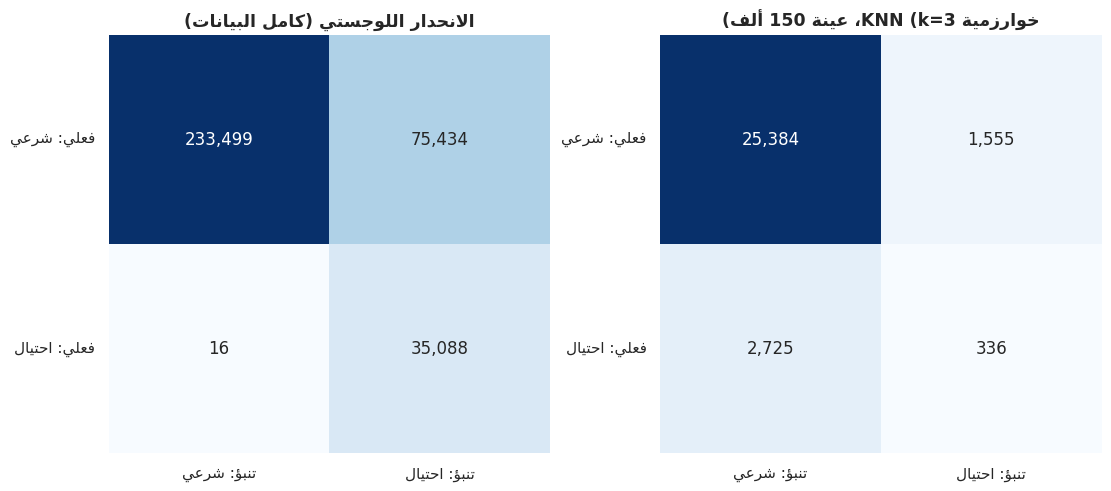

In [20]:
# ---- الرسم 7: مصفوفات الالتباس ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
for ax, key, title in [
    (axes[0], "logistic_regression_full", "الانحدار اللوجستي (كامل البيانات)"),
    (axes[1], "knn_sample", f"خوارزمية KNN (k={best_k}، عينة 150 ألف)"),
]:
    cm = np.array(results[key]["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
                cbar=False, annot_kws={"size": 12})
    ax.set_xticklabels([ar("تنبؤ: شرعي"), ar("تنبؤ: احتيال")], fontsize=11)
    ax.set_yticklabels([ar("فعلي: شرعي"), ar("فعلي: احتيال")],
                       rotation=0, fontsize=11)
    ax.set_title(ar(title), fontsize=12.5, fontweight="bold")
plt.show()

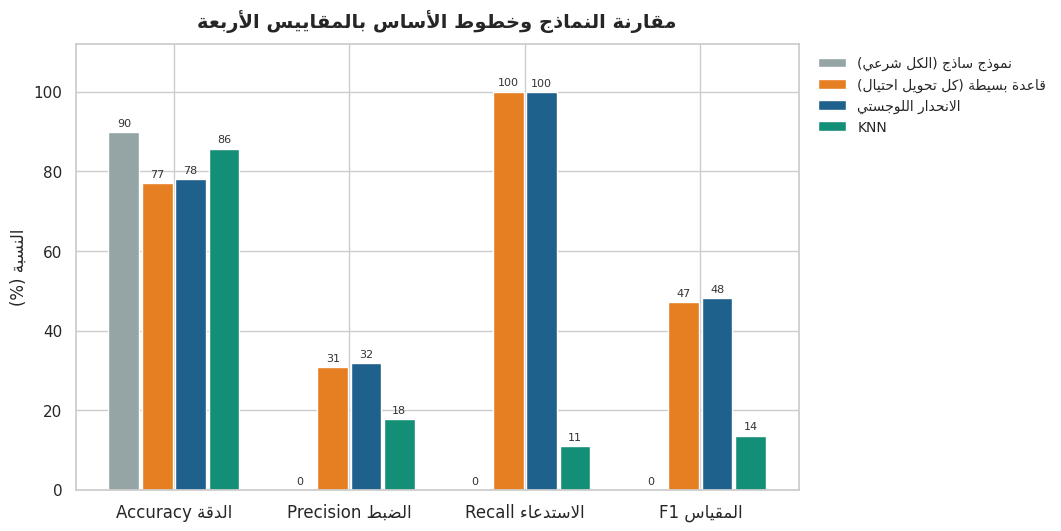

In [21]:
# ---- الرسم 8: مقارنة النماذج بالمقاييس الأربعة ----
models = [
    ("dumb_all_legal", "نموذج ساذج (الكل شرعي)", C_DUMB),
    ("rule_every_transfer", "قاعدة بسيطة (كل تحويل احتيال)", C_RULE),
    ("logistic_regression_full", "الانحدار اللوجستي", C_LR),
    ("knn_sample", "KNN", C_KNN),
]
metrics_lbl = [("accuracy", "الدقة Accuracy"), ("precision", "الضبط Precision"),
               ("recall", "الاستدعاء Recall"), ("f1", "المقياس F1")]
fig, ax = plt.subplots(figsize=(10.5, 5.2), constrained_layout=True)
x = np.arange(len(metrics_lbl)); n = len(models); bw = 0.19
for i, (key, label, color) in enumerate(models):
    vals = [results[key][m] * 100 for m, _ in metrics_lbl]
    bars = ax.bar(x + (i - (n - 1) / 2) * bw, vals, width=bw * 0.92,
                  color=color, label=ar(label))
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.0f}", xy=(b.get_x() + b.get_width() / 2, v + 1.5),
                    ha="center", fontsize=8, color="#333333")
ax.set_xticks(x)
ax.set_xticklabels([ar(lbl) for _, lbl in metrics_lbl], fontsize=12)
ax.set_ylabel(ar("النسبة (%)"), fontsize=12)
ax.set_ylim(0, 112)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=10, frameon=False)
ax.set_title(ar("مقارنة النماذج وخطوط الأساس بالمقاييس الأربعة"),
             fontsize=14, fontweight="bold", pad=12)
plt.show()

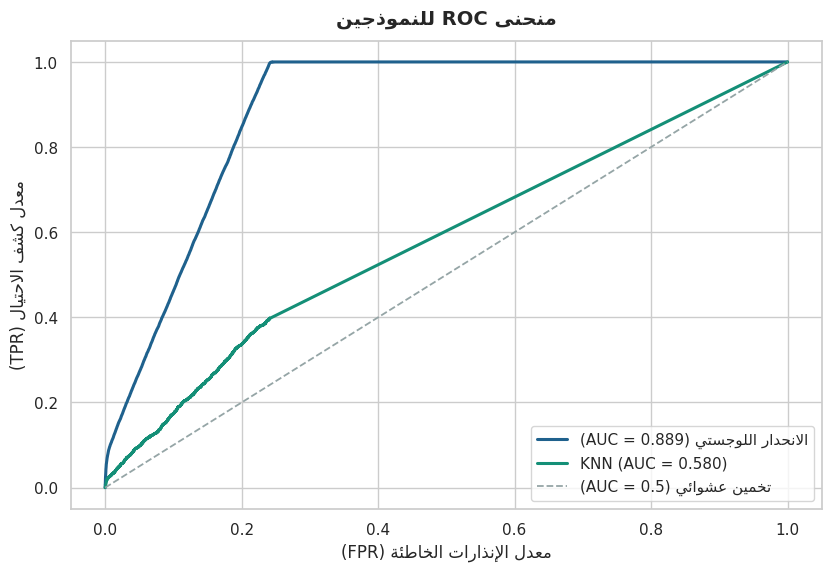

In [22]:
# ---- الرسم 9: منحنيات ROC ----
fig, ax = plt.subplots(figsize=(8.2, 5.6), constrained_layout=True)
fpr_l, tpr_l, _ = roc_curve(y_test, lr_prob)
ax.plot(fpr_l, tpr_l, color=C_LR, linewidth=2.2,
        label=ar(f"الانحدار اللوجستي (AUC = {results['logistic_regression_full']['roc_auc']:.3f})"))
fpr_k, tpr_k, _ = roc_curve(ys_te, knn_prob)
ax.plot(fpr_k, tpr_k, color=C_KNN, linewidth=2.2,
        label=ar(f"KNN (AUC = {results['knn_sample']['roc_auc']:.3f})"))
ax.plot([0, 1], [0, 1], color=C_DUMB, linestyle="--", linewidth=1.3,
        label=ar("تخمين عشوائي (AUC = 0.5)"))
ax.set_xlabel(ar("معدل الإنذارات الخاطئة (FPR)"), fontsize=12)
ax.set_ylabel(ar("معدل كشف الاحتيال (TPR)"), fontsize=12)
ax.legend(loc="lower right", fontsize=11, frameon=True)
ax.set_title(ar("منحنى ROC للنموذجين"), fontsize=14, fontweight="bold", pad=12)
plt.show()

## المرحلة الرابعة: تحليل الإشارة — لماذا لا يتفوق النموذج على القاعدة البسيطة؟

لاحظنا أن LR تجاوز القاعدة البسيطة بهامش ضيق فقط (ضبط 31.75% مقابل 30.79% عند استدعاء شبه كامل). السؤال البحثي: **هل يوجد فعلاً إشارة إضافية داخل التحويلات يمكن للنموذج تعلمها؟**

نختبر القدرة التمييزية لكل إشارة مرشحة داخل التحويلات فقط (حيث يقع الاحتيال كله) بمقياس AUC: الميزات الفردية، تكرار الحسابات، درجة خطورة الحساب (ترميز هدف منعَّم محسوب من بيانات التدريب فقط لمنع التسريب)، والإشارات التسلسلية (ترتيب الوصول، العملية السابقة، الزمن بين العمليات). **AUC = 0.5 يعني إشارة عديمة القوة التمييزية.**

In [23]:
# ===== تحليل الإشارة داخل التحويلات (569,328 عملية) =====
tr = df[df["transactionType"] == "TRANSFER"].sort_values("step")
y_tr = tr["isFraud"].values
signals = {}

# 1) الميزات الفردية
single = {
    "المبلغ": tr["amount"].values,
    "رصيد المُرسل قبل": tr["oldBalInitiator"].values,
    "رصيد المستقبِل قبل": tr["oldBalRecipient"].values,
    "الفجوة النسبية": ((tr["amount"] - tr["oldBalInitiator"]) / (tr["amount"] + 1)).values,
    "خطأ إثبات رصيد المستقبِل": ((tr["newBalRecipient"] - tr["oldBalRecipient"])
                                - tr["amount"]).values,
    "الخطوة الزمنية": tr["step"].values,
}
for name, vals in single.items():
    signals[name] = round(float(roc_auc_score(y_tr, vals)), 4)
    print(f"   {name:34s}: AUC = {signals[name]:.4f}")

# 2) تكرار الحسابات ودرجة الخطورة (من التدريب فقط — بلا تسريب)
tr_train, tr_test = train_test_split(tr, test_size=0.2,
                                     stratify=tr["isFraud"], random_state=42)
glob_rate = tr_train["isFraud"].mean()
m = 20.0   # معامل التنعيم

rec_stats = tr_train.groupby("recipient")["isFraud"].agg(["sum", "count"])
rec_risk = (rec_stats["sum"] + m * glob_rate) / (rec_stats["count"] + m)
signals["درجة خطورة المستقبِل (ترميز هدف)"] = round(float(roc_auc_score(
    tr_test["isFraud"], tr_test["recipient"].map(rec_risk).fillna(glob_rate))), 4)

rec_cnt = tr_train.groupby("recipient").size()
signals["تكرار استقبال الحساب"] = round(float(roc_auc_score(
    tr_test["isFraud"], tr_test["recipient"].map(rec_cnt).fillna(0))), 4)

init_stats = tr_train.groupby("initiator")["isFraud"].agg(["sum", "count"])
init_risk = (init_stats["sum"] + m * glob_rate) / (init_stats["count"] + m)
signals["درجة خطورة المُرسل (ترميز هدف)"] = round(float(roc_auc_score(
    tr_test["isFraud"], tr_test["initiator"].map(init_risk).fillna(glob_rate))), 4)

# 3) الإشارات التسلسلية (على كامل تسلسل التحويلات — إحصاء وصفي)
signals["ترتيب الوصول ضمن المستقبِل"] = round(float(roc_auc_score(
    y_tr, tr.groupby("recipient").cumcount().values)), 4)

prev = tr.groupby("recipient")["isFraud"].shift(1)
mask = prev.notna()
signals["هل العملية السابقة للمستقبِل احتيال؟"] = round(float(roc_auc_score(
    y_tr[mask.values], prev[mask].values)), 4)

last_step = tr.groupby("initiator")["step"].shift(1)
mask_t = last_step.notna()
signals["الزمن منذ آخر عملية للمُرسل"] = round(float(roc_auc_score(
    y_tr[mask_t.values], (tr["step"] - last_step)[mask_t].values)), 4)

for k in ["درجة خطورة المستقبِل (ترميز هدف)", "تكرار استقبال الحساب",
          "درجة خطورة المُرسل (ترميز هدف)", "ترتيب الوصول ضمن المستقبِل",
          "هل العملية السابقة للمستقبِل احتيال؟", "الزمن منذ آخر عملية للمُرسل"]:
    print(f"   {k:34s}: AUC = {signals[k]:.4f}")

   المبلغ                            : AUC = 0.4698
   رصيد المُرسل قبل                  : AUC = 0.4505
   رصيد المستقبِل قبل                : AUC = 0.4766


   الفجوة النسبية                    : AUC = 0.5136
   خطأ إثبات رصيد المستقبِل          : AUC = 0.4814
   الخطوة الزمنية                    : AUC = 0.4852


   درجة خطورة المستقبِل (ترميز هدف)  : AUC = 0.5184
   تكرار استقبال الحساب              : AUC = 0.5181
   درجة خطورة المُرسل (ترميز هدف)    : AUC = 0.5445
   ترتيب الوصول ضمن المستقبِل        : AUC = 0.5016
   هل العملية السابقة للمستقبِل احتيال؟: AUC = 0.5075
   الزمن منذ آخر عملية للمُرسل       : AUC = 0.5113


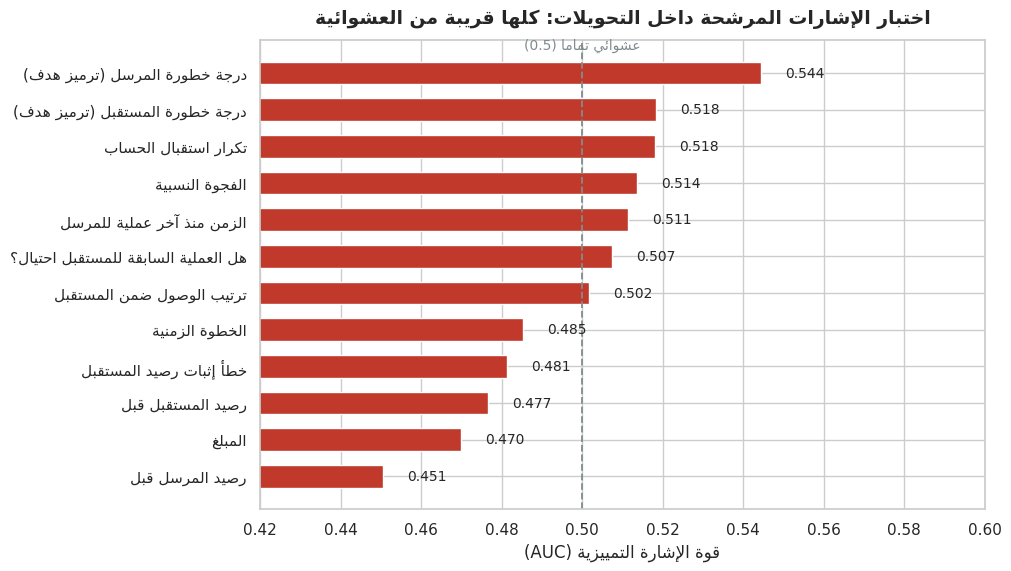

In [24]:
# ---- الرسم 10: قوة الإشارات التمييزية ----
fig, ax = plt.subplots(figsize=(10, 5.6), constrained_layout=True)
names = list(signals.keys())
vals = [signals[n] for n in names]
order = np.argsort(vals)
names = [names[i] for i in order]; vals = [vals[i] for i in order]
colors = ["#C0392B" if v < 0.55 else "#2E86AB" for v in vals]
bars = ax.barh([ar(n) for n in names], vals, color=colors, height=0.62)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:.3f}", xy=(v + 0.006, b.get_y() + b.get_height() / 2),
                va="center", fontsize=10)
ax.axvline(0.5, color="#7F8C8D", linestyle="--", linewidth=1.3)
ax.annotate(ar("عشوائي تماماً (0.5)"), xy=(0.5, len(names) - 0.35),
            fontsize=10, color="#7F8C8D", ha="center")
ax.set_xlim(0.42, 0.60)
ax.set_xlabel(ar("قوة الإشارة التمييزية (AUC)"), fontsize=12)
ax.set_title(ar("اختبار الإشارات المرشحة داخل التحويلات: كلها قريبة من العشوائية"),
             fontsize=13.5, fontweight="bold", pad=12)
plt.show()

## الخلاصة والتوصيات

**أبرز النتائج:**

| النموذج | الدقة | الضبط | الاستدعاء | F1 | AUC |
|---|---|---|---|---|---|
| نموذج ساذج (الكل شرعي) | 89.80% | 0% | 0% | 0% | — |
| قاعدة بسيطة (كل تحويل احتيال) | 77.07% | 30.79% | 100% | 47.09% | — |
| **الانحدار اللوجستي (كامل البيانات)** | 78.07% | **31.75%** | **99.95%** | **48.19%** | **0.889** |
| KNN (k=3، عينة) | 85.73% | 17.77% | 10.98% | 13.57% | 0.580 |

**ثلاثة دروس جوهرية من المشروع:**

1. **فخ الدقة:** النموذج الساذج يحقق أعلى دقة في الجدول (89.80%) لأنه يغتنم اختلال الفئات، لكنه يمسك بصفر عمليات احتيال — فالمقياس العادل في مسائل الكشف عن الأحداث النادرة هو الاستدعاء والضبط معاً لا الدقة وحدها.
2. **قيمة خطوط الأساس:** القاعدة البسيطة المستخلصة من الاستكشاف (كل تحويل = احتيال) تحقق استدعاء كاملاً لكنها تتهم 78,894 بريئاً؛ والانحدار اللوجستي يتجاوزها في المقاييس الأربعة جميعها بفضل الميزات الهندسية، مع ميزة إضافية: احتمالية قابلة للضبط بدل إجابة نعم/لا جامدة.
3. **سقف الأداء:** اختبرنا 12 إشارة مرشحة داخل التحويلات (المبالغ، الأرصدة، تكرار الحسابات، درجات الخطورة، الإشارات التسلسلية) فجاءت كلها قريبة من العشوائية (AUC بين 0.45 و0.545)، بينما تعطي إشارة نوع العملية وحدها 0.873 على كامل البيانات — أي أن الاحتيال شبه عشوائي داخل التحويلات في هذه البيانات التركيبية، وهو ما يفسر بلوغ النموذج حدّ القاعدة. أما KNN فقد فشل لأن الإشارة الفعالة تكاد تكون أحادية البعد (نوع العملية) بينما تُحسب المسافات عبر 16 بُعداً فتضيع الإشارة في الضجيج.

**التوصيات المستقبلية:**

- إغناء البيانات بخصائص سلوكية وشبكية (بصمة الجهاز، حدود السرعة، تحليل شبكة الحسابات) قبل توسيع النمذجة.
- ضبط عتبة الاحتمالية وفق كلفة كل نوع من الأخطاء (كلفة الإنذار الخاطئ مقابل كلفة تسريب الاحتيال) عبر منحنى ROC.
- تجربة نماذج شجكية (أشجار القرار / الغابات العشوائية) رغم أن سقف الإشارة يظل القيد الحاكم.